In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from hmmlearn.hmm import GaussianHMM
from hmmlearn import _hmmc
from sklearn.preprocessing import StandardScaler
import os


## Description

- Goal: implement MVO to determine optimal portfolio weights with state-conditional asset returns and covariance matrix
- Methodology:
  - Step 1: Use 13 macroeconomic indicators to classify states (number of states initially set to be 2)
  - Step 2: Once states are classified (according to sorted probabilities), estimate the mean and the covariance matrix (historical or more advanced methods, especially for the covariance matrix)
  - Step 3: Implement MVO for each of the state to determine optimal portfolio weights (for three assets: equity, gold and bond)
  - Step 4: Compare with static portfolios and backtest on historical test data

- Theoretical framework for Step 1: Two related hidden models
  - Plain vanilla HMM where conditional on the states which are assumed to follow a Markov chain, the observables are iid (Gaussian, for e.g.)
  - Markov Switching model (MSM): Even conditional on the states, the observables are allowed to exhibit serial correlation (for e.g., follow an AR(1))

In this notebook, we will be implementing Steps 1-4 for the HMM model using the `hmmlearn` package.

## Data prepration

First we need to standardize macroeconomic indicators. This is essentially as series having vastly different scales might lead to poorly conditioned covariance matrix and the EM algorithm struggling to converge. We also need to split the data into train and test sets.

In [96]:
def prepare_macro_data(macro_df, train_end_idx: int=None):
    """
    Prepares macroeconomic data for HMM training and testing.

    Parameters
    ----------
    macro_df      : pd.DataFrame of shape (T, n) — raw macro indicators
    train_end_idx : int — last training index; if None, use all data
 
    Returns
    -------
    X_train  : (T_train, n) standardized training array
    X_test   : (T_test, n) standardized test array (or None)
    scaler   : fitted StandardScaler (needed for out-of-sample)
    dates_train, dates_test
    """

    values = macro_df.values.astype(float)
    dates = macro_df.index

    if train_end_idx is None:
        train_end_idx = len(values)

    X_raw_train = values[:train_end_idx]
    X_raw_test = values[train_end_idx:] if train_end_idx < len(values) else None 

    # Fit scaler only on training data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_raw_train)
    X_test = scaler.transform(X_raw_test) if X_raw_test is not None else None

    dates_train = dates[:train_end_idx]
    dates_test = dates[train_end_idx:] if train_end_idx < len(dates) else None

    return X_train, X_test, scaler, dates_train, dates_test

In [97]:
data_path = os.path.join("..", "data", "macro_clean.csv")
macro_df = pd.read_csv(data_path, index_col=0, parse_dates=True)
macro_df.head()

,industrial_production,real_person_income,unemployment_rate,initial_jobless_claims,cpi,oil_price,vix,credit_spread,yield_curve_slope,fed_funds_rate,consumer_sentiment,housing_starts,m2_money_supply
1990-02-28,0.766531,0.212161,-0.176815,0.086523,0.648227,-0.517277,0.338459,-0.860618,-1.015353,0.112648,-0.816259,-0.973845,-0.117535
1990-03-31,0.370694,-0.144198,-0.176815,-0.056857,0.933078,-0.577370,0.033559,-1.001067,-1.092009,0.277788,0.453545,-1.387900,-0.208114
1990-04-30,-0.367467,0.581797,0.366229,0.272514,0.056672,-0.934117,0.005227,-1.113426,-1.015353,-0.052492,0.645214,-0.410427,-0.175312
1990-05-31,0.182830,-0.439503,0.004200,-0.054564,-0.234552,-0.572546,-0.284832,-0.818483,-0.993451,-0.382773,-0.768342,-0.371336,-0.905236
1990-06-30,0.216754,-0.099147,-0.357829,0.083436,1.493735,-0.255118,-0.537116,-0.706123,-0.894894,0.663116,-0.528756,-0.371754,-0.084565


In [98]:
macro_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   industrial_production   431 non-null    float64
 1   real_person_income      431 non-null    float64
 2   unemployment_rate       431 non-null    float64
 3   initial_jobless_claims  431 non-null    float64
 4   cpi                     431 non-null    float64
 5   oil_price               431 non-null    float64
 6   vix                     431 non-null    float64
 7   credit_spread           431 non-null    float64
 8   yield_curve_slope       431 non-null    float64
 9   fed_funds_rate          431 non-null    float64
 10  consumer_sentiment      431 non-null    float64
 11  housing_starts          431 non-null    float64
 12  m2_money_supply         431 non-null    float64
dtypes: float64(13)
memory usage: 47.1 KB


In [99]:
# train_length = int(0.8 * len(macro_df))
X_train, X_test, scaler, dates_train, dates_test = prepare_macro_data(macro_df)

In [100]:
X_train.shape, X_test.shape if X_test is not None else None

((431, 13), None)

## Model fitting

We will now fit an HMM to the standardized train data.

In [101]:
def fit_hmm(
        X_train: np.ndarray,
        K: int = 2,
        n_iter: int = 200,
        n_restarts: int = 10,
        tol: float = 1e-6, 
        random_state: int = 42
) -> GaussianHMM:
    """
    Fits a Gaussian HMM to the training data.

    Parameters
    ----------
    X_train      : (T_train, n) standardized training array
    K            : int — number of hidden states (regimes)
    n_iter       : int — max EM iterations per restart
    n_restarts   : int — number of random restarts for best model (avoid getting stuck in local optima)
    tol          : float — convergence threshold on log-likelihood improvement
    random_state : int — random seed for reproducibility (+1 per restart)

    Returns
    -------
    best_model : fitted GaussianHMM with highest log-likelihood
    """
    
    best_model = None
    best_loglik = -np.inf

    for i in range(n_restarts):
        model = GaussianHMM(
            n_components = K, 
            covariance_type = 'full', 
            n_iter = n_iter, 
            tol = tol,
            init_params = 'stmc',  # initialize startprob, transmat, means, covars
            random_state = random_state + i
        )
        # Run Baum-Welch EM algorithm to fit the model
        try:
            model.fit(X_train)
            loglik = model.score(X_train)

            if loglik > best_loglik:
                best_loglik = loglik
                best_model = model
        except Exception as e:
            # Occassionally EM can fail to converge or encounter numerical issues; we catch and move on
            print(f"Restart {i} failed: {e}")
            continue
    print(f"Best log-likelihood (per sample): {best_loglik:.4f}")
    return best_model

In [102]:
model = fit_hmm(X_train, K=2, n_iter=200, n_restarts=10, tol=1e-6, random_state=42)

Best log-likelihood (per sample): -5691.9189


In [103]:
model.means_.shape

(2, 13)

In [104]:
model.covars_.shape

(2, 13, 13)

## Extracting results

### Smoothed probabilities

In [105]:
def get_smoothed_probs(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """ 
    Computes smoothed state probabilities for each time point.
    Parameters
    ----------
    model : The trained Gaussian HMM.
    X     : np.ndarray of input data.

    Returns
    -------
    (K, T) np.ndarray of smoothed state probabilities.
    """
    return model.predict_proba(X).T

In [106]:
smoothed_probs_train = get_smoothed_probs(model, X_train)
smoothed_probs_train.shape

(2, 431)

In [107]:
# check if smoothed probabilities sum to 1 at each time point
smoothed_sums = smoothed_probs_train.sum(axis=0)
np.allclose(smoothed_sums, 1.0)

True

In [108]:
pd.DataFrame(smoothed_probs_train.T, index=dates_train, columns=[f"State {i}" for i in range(model.n_components)]).head()

,State 0,State 1
1990-02-28,1.0,1.684182e-295
1990-03-31,1.0,1.368005e-08
1990-04-30,1.0,1.240050e-07
1990-05-31,1.0,2.777758e-09
1990-06-30,1.0,1.244286e-08


### Filtered probabilities

In [109]:
def get_filtered_probs(model, X):
    """
    Computes filtered state probabilities: P(S_t=k | y_{1:t})
    Parameters
    ----------
    model : The trained Gaussian HMM.
    X     : np.ndarray of input data.

    Returns
    -------
    (K, T) np.ndarray of filtered state probabilities.
    """
    T = X.shape[0]
    K = model.n_components

    log_emit = model._compute_log_likelihood(X)   # (T,K)
    emit = np.exp(log_emit)

    alpha = np.zeros((T, K))

    # t=0
    alpha[0] = model.startprob_ * emit[0]
    alpha[0] /= alpha[0].sum()

    # recursion
    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ model.transmat_) * emit[t]
        s = alpha[t].sum()
        if s > 0:
            alpha[t] /= s
        else:
            alpha[t] = np.ones(K) / K

    return alpha.T

In [110]:
filtered_probs_train = get_filtered_probs(model, X_train)
filtered_probs_train.shape

(2, 431)

In [111]:
# check that filtered probabilities sum to 1 at each time point
filtered_sums = filtered_probs_train.sum(axis=0)
np.allclose(filtered_sums, 1.0)

True

In [112]:
pd.DataFrame(filtered_probs_train.T, index=dates_train, columns=[f"State {i}" for i in range(model.n_components)]).head()

,State 0,State 1
1990-02-28,1.0,5.639649e-295
1990-03-31,1.0,4.580857e-08
1990-04-30,1.0,4.152432e-07
1990-05-31,1.0,9.301596e-09
1990-06-30,1.0,4.166617e-08


### Hidden states (most likely sequence)

In [113]:
states_sequence = model.predict(X_train)
states_sequence.shape

(431,)

In [114]:
# unique states in sequence and their counts
np.unique(states_sequence, return_counts=True)

(array([0, 1]), array([394,  37]))

## Plotting results

In [119]:
def plot_hmm_states(dates, states, title="HMM Regime States"):
    """
    Plots the inferred HMM states over time.

    Parameters
    ----------
    dates  : array-like of datetime — time index for x-axis
    states : array-like of int — inferred state sequence (0 to K-1)
    title  : str — plot title
    """
    plt.figure(figsize=(12, 4))
    plt.plot(dates, states, drawstyle='steps-post', marker='o')
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Inferred State")
    plt.yticks(np.unique(states))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_hmm_state_probs(dates, probs, title="HMM State Probabilities"):
    """
    Plots the HMM state probabilities over time.

    Parameters
    ----------
    dates : array-like of datetime — time index for x-axis
    probs : (K, T) np.ndarray of state probabilities
    title : str — plot title
    """
    plt.figure(figsize=(12, 4))
    probs_df = pd.DataFrame(probs.T, index=dates, columns=[f"State {i}" for i in range(probs.shape[0])])
    probs_df.plot(ax=plt.gca())
    plt.xlabel('Date')
    plt.ylabel('Probability')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

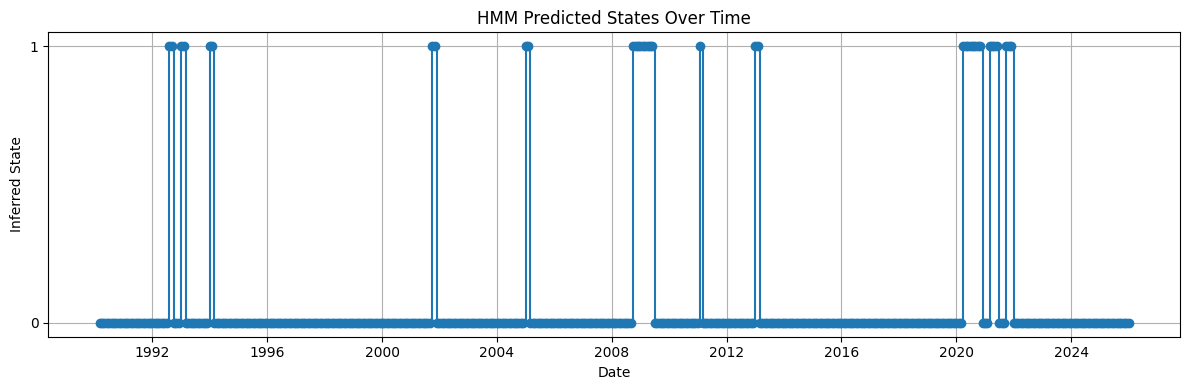

In [120]:
plot_hmm_states(dates_train, states_sequence, title="HMM Predicted States Over Time")

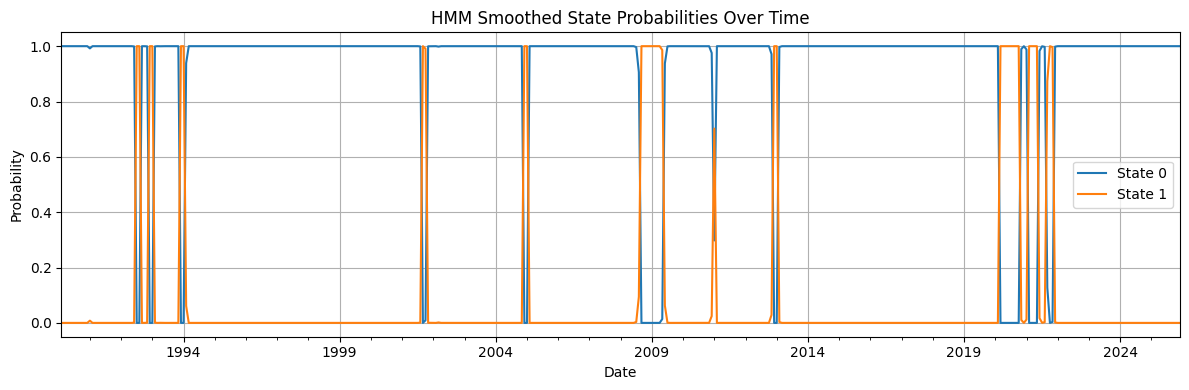

In [121]:
plot_hmm_state_probs(dates_train, smoothed_probs_train, title="HMM Smoothed State Probabilities Over Time")

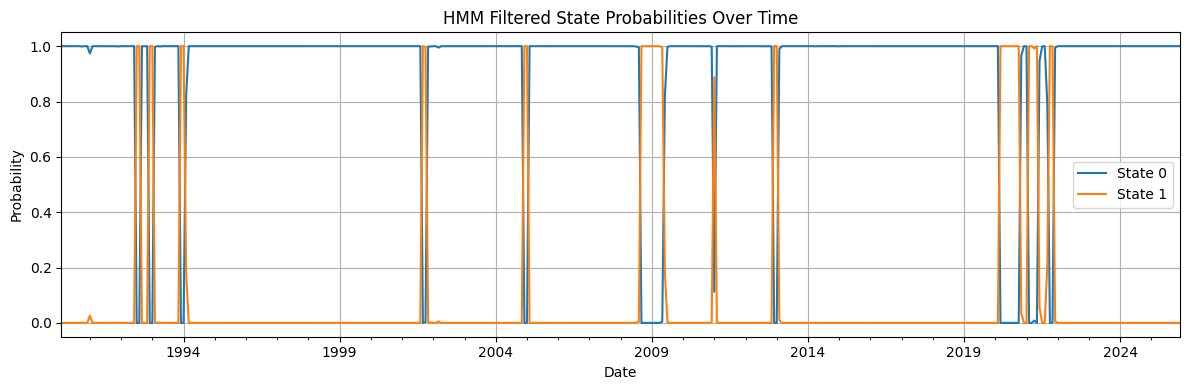

In [122]:
plot_hmm_state_probs(dates_train, filtered_probs_train, title="HMM Filtered State Probabilities Over Time")